# EDA — CEDEARs Screener

Análisis exploratorio sobre el warehouse `data/warehouse.duckdb` que arma el resto del proyecto:

- **`dim_empresa`** — identidad + sector/industria/país (una fila por empresa)
- **`fact_metrics_daily`** — ratios de valuación y momentum fundamental (una fila por empresa y día — hoy todavía tiene un solo día cargado, así que este notebook lo trata como una foto del momento, no como serie de tiempo)
- **`fact_precios_daily`** — OHLCV diario, 5 años de historia
- **`fact_macro_daily`** — series macro (tasas, VIX, FX, commodities, índices), una fila por serie y día

Objetivo: entender qué hay en los datos antes de construir cualquier score o agente encima — calidad de datos, distribuciones, outliers, y relaciones entre variables (value vs growth, sector vs valuación, etc.).

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

con = duckdb.connect("../data/warehouse.duckdb", read_only=True)

dim_empresa = con.execute("SELECT * FROM dim_empresa").fetchdf()
metrics = con.execute("SELECT * FROM fact_metrics_daily").fetchdf()
precios = con.execute("SELECT * FROM fact_precios_daily").fetchdf()

print("dim_empresa:", dim_empresa.shape)
print("fact_metrics_daily:", metrics.shape)
print("fact_precios_daily:", precios.shape)

dim_empresa: (424, 14)
fact_metrics_daily: (1114, 29)
fact_precios_daily: (515441, 8)


## 1. Calidad de datos

Antes de analizar nada: cuántos nulls hay por columna. Un campo con muchos nulls no es necesariamente un bug — puede ser una limitación real de la fuente (ej. `eps_growth_5y_pct` casi siempre va a estar vacío porque Yahoo gratis no da 6 años de historia, ver `analisis_fundamental_pesado.py`).

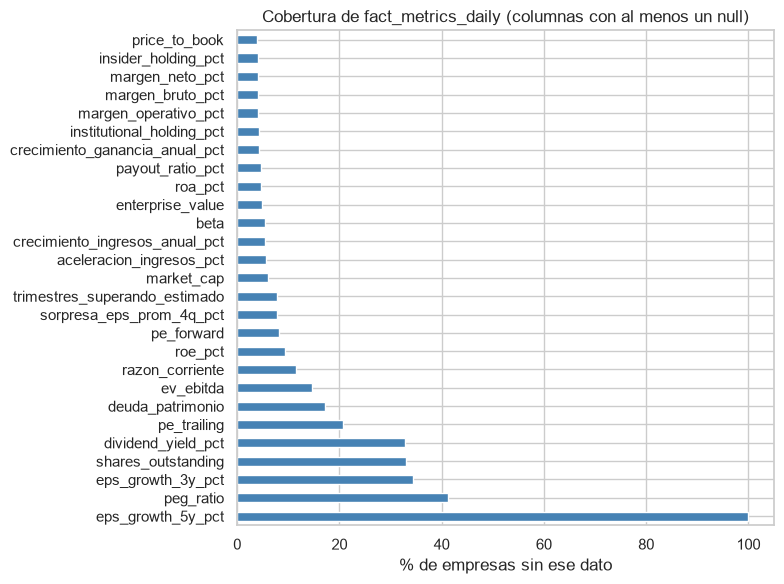

eps_growth_5y_pct                 100.0
peg_ratio                          41.2
eps_growth_3y_pct                  34.4
shares_outstanding                 33.1
dividend_yield_pct                 32.9
pe_trailing                        20.6
deuda_patrimonio                   17.1
ev_ebitda                          14.7
razon_corriente                    11.6
roe_pct                             9.3
pe_forward                          8.1
sorpresa_eps_prom_4q_pct            7.8
trimestres_superando_estimado       7.8
market_cap                          6.1
aceleracion_ingresos_pct            5.6
crecimiento_ingresos_anual_pct      5.5
beta                                5.5
enterprise_value                    4.8
roa_pct                             4.7
payout_ratio_pct                    4.6
crecimiento_ganancia_anual_pct      4.3
institutional_holding_pct           4.2
margen_operativo_pct                4.1
margen_bruto_pct                    4.1
margen_neto_pct                     4.1


In [2]:
nulls = metrics.isna().mean().sort_values(ascending=False) * 100
nulls = nulls[nulls > 0].round(1)

fig, ax = plt.subplots(figsize=(8, 6))
nulls.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("% de empresas sin ese dato")
ax.set_title("Cobertura de fact_metrics_daily (columnas con al menos un null)")
plt.tight_layout()
plt.show()

nulls

## 2. Universo por sector y mercado

`lynch_category` todavía está vacía para las 340 empresas (es la clasificación pendiente que vamos a hacer con ayuda de un LLM). Por ahora, `sector`/`industria` de Yahoo son la única forma de agrupar.

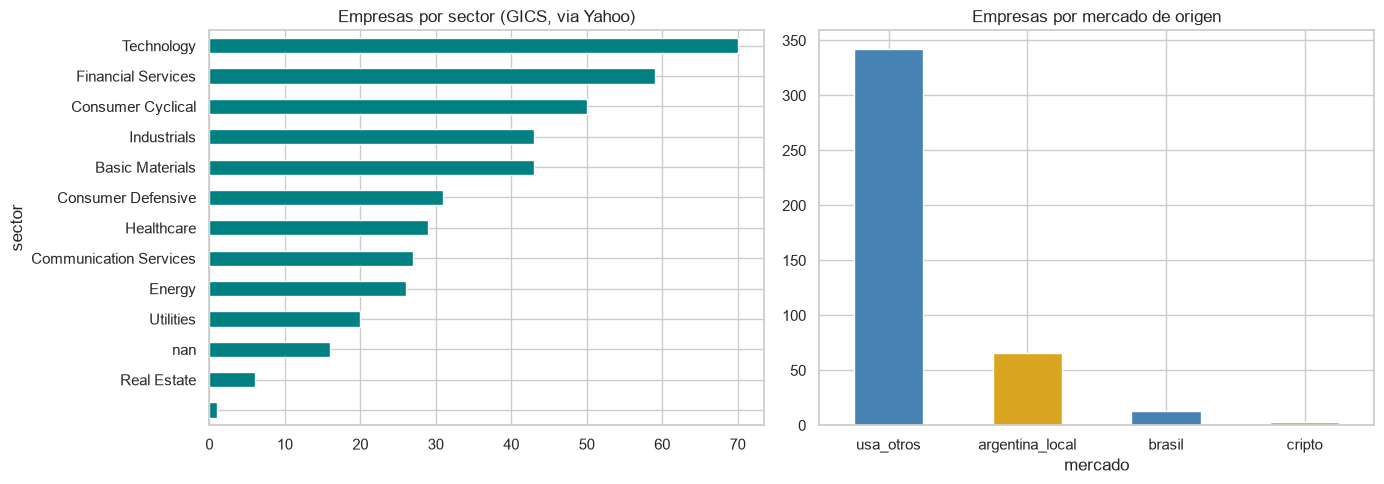

Sin sector clasificado: 3 de 424


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dim_empresa["sector"].value_counts().plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Empresas por sector (GICS, via Yahoo)")
axes[0].invert_yaxis()

dim_empresa["mercado"].value_counts().plot(kind="bar", ax=axes[1], color=["steelblue", "goldenrod"])
axes[1].set_title("Empresas por mercado de origen")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print(f"Sin sector clasificado: {dim_empresa['sector'].isna().sum()} de {len(dim_empresa)}")

## 3. Distribución de ratios de valuación

Los ratios de valuación tienen outliers extremos por naturaleza (una empresa con ganancia casi cero da un P/E disparatado). Para ver la distribución "típica" recortamos al percentil 1-99 solo para graficar — el dato original en `metrics` queda intacto.

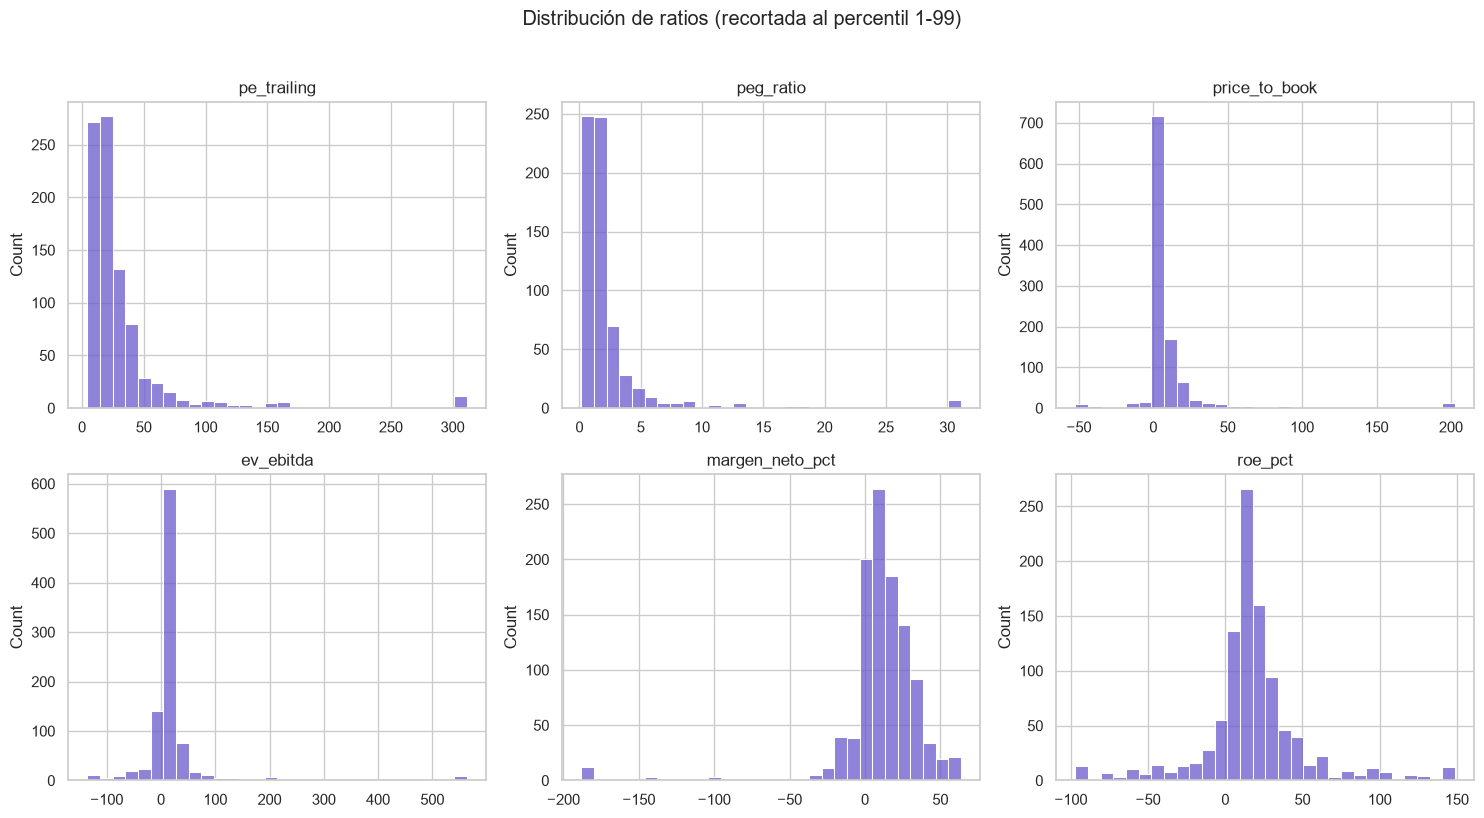

C:\Users\Usuario\guia\cedears-data-pipeline\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,pe_trailing,peg_ratio,price_to_book,ev_ebitda,margen_neto_pct,roe_pct
count,885.00,655.00,1072.00,950.00,1068.00,1010.00
mean,inf,2.89,12.96,41.11,11.87,15.68
std,NaN,8.92,97.07,330.61,36.23,57.11
min,0.71,0.04,-307.06,-743.76,-230.60,-1056.70
25%,13.32,0.90,1.42,5.18,3.20,5.90
50%,20.49,1.48,2.98,11.34,11.30,14.70
75%,33.04,2.20,8.28,21.68,24.70,27.00
max,inf,116.61,1563.04,7018.43,668.70,267.40


In [4]:
ratios = ["pe_trailing", "peg_ratio", "price_to_book", "ev_ebitda", "margen_neto_pct", "roe_pct"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, ratios):
    serie = metrics[col].dropna()
    lo, hi = serie.quantile([0.01, 0.99])
    sns.histplot(serie.clip(lo, hi), bins=30, ax=ax, color="slateblue")
    ax.set_title(col)
    ax.set_xlabel("")

plt.suptitle("Distribución de ratios (recortada al percentil 1-99)", y=1.02)
plt.tight_layout()
plt.show()

metrics[ratios].describe().round(2)

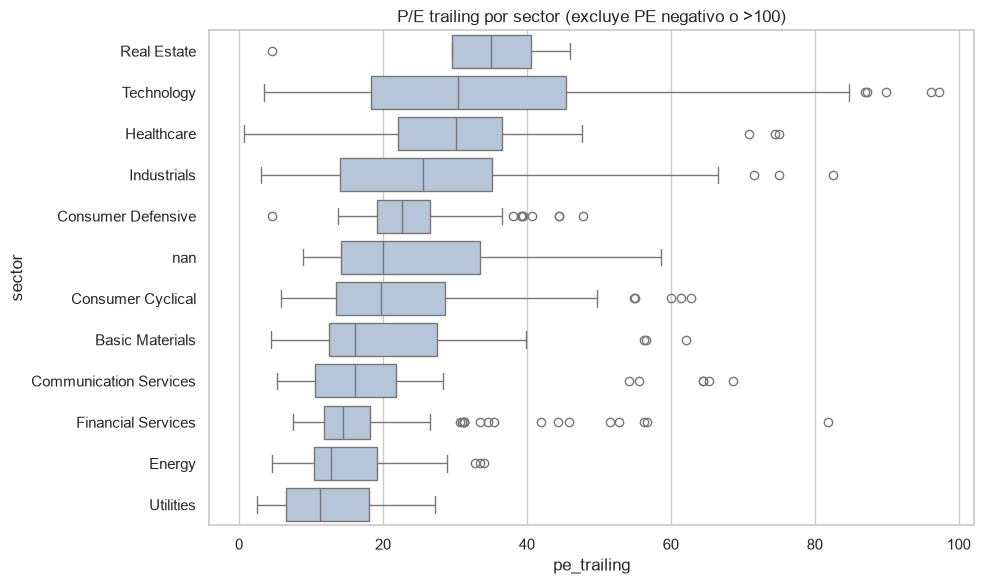

In [5]:
m = metrics.merge(dim_empresa[["ticker_usd", "sector"]], on="ticker_usd")
m_pe = m[(m["pe_trailing"] > 0) & (m["pe_trailing"] < 100) & m["sector"].notna()]  # PE negativo o absurdo no aporta a comparar

orden = m_pe.groupby("sector")["pe_trailing"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=m_pe, y="sector", x="pe_trailing", order=orden, ax=ax, color="lightsteelblue")
ax.set_title("P/E trailing por sector (excluye PE negativo o >100)")
plt.tight_layout()
plt.show()

## 4. Crecimiento y momentum

`crecimiento_ingresos_anual_pct` es el YoY del último balance anual. `aceleracion_ingresos_pct` compara esa tasa contra la anterior: positivo = viene creciendo cada vez más rápido, negativo = viene desacelerando (aunque siga creciendo fuerte, como vimos con NVDA).

In [6]:
crecimiento = metrics.merge(dim_empresa[["ticker_usd", "nombre_empresa", "sector"]], on="ticker_usd")
crecimiento = crecimiento.dropna(subset=["crecimiento_ingresos_anual_pct"])

top15 = crecimiento.nlargest(15, "crecimiento_ingresos_anual_pct")
bottom15 = crecimiento.nsmallest(15, "crecimiento_ingresos_anual_pct")

cols = ["ticker_usd", "nombre_empresa", "sector", "crecimiento_ingresos_anual_pct", "aceleracion_ingresos_pct"]
print("Top 15 crecimiento de ingresos YoY:")
display(top15[cols])
print("\nBottom 15 (mayor caída de ingresos):")
display(bottom15[cols])

Top 15 crecimiento de ingresos YoY:


,ticker_usd,nombre_empresa,sector,crecimiento_ingresos_anual_pct,aceleracion_ingresos_pct
31,ASTS,Ast Spacemobile Inc,Technology,1505.2,1605.2
371,ASTS,Ast Spacemobile Inc,Technology,1505.2,1605.2
725,ASTS,Ast Spacemobile Inc,Technology,1505.2,1605.2
220,ONDS,Ondas Holdings Inc,Technology,605.3,659.4
566,ONDS,Ondas Holdings Inc,Technology,605.3,659.4
920,ONDS,Ondas Holdings Inc,Technology,605.3,659.4
201,NBIS,Nebius Group N.V,Communication Services,479.0,-354.7
547,NBIS,Nebius Group N.V,Communication Services,479.0,-354.7
901,NBIS,Nebius Group N.V,Communication Services,479.0,-354.7
601,SNDK,Sandisk Corporation,Technology,175.3,164.9



Bottom 15 (mayor caída de ingresos):


,ticker_usd,nombre_empresa,sector,crecimiento_ingresos_anual_pct,aceleracion_ingresos_pct
326,SPCE,Virgin Galactic Holdings Inc,Industrials,-78.1,-81.5
677,SPCE,Virgin Galactic Holdings Inc,Industrials,-78.1,-81.5
1031,SPCE,Virgin Galactic Holdings Inc,Industrials,-78.1,-81.5
1078,GCDI,Gcdi S.A. Acciones Ord Esc,Real Estate,-53.9,-60.9
1053,BHIP,Banco Hipotecario,Financial Services,-51.8,-75.0
1052,VALO,Banco De Valores S.A,Financial Services,-41.7,-16.3
1087,ROSE,Instituto Rosenbusch,Healthcare,-41.2,-51.6
196,MRNA,Moderna Inc,Healthcare,-39.9,12.7
540,MRNA,Moderna Inc,Healthcare,-39.9,12.7
894,MRNA,Moderna Inc,Healthcare,-39.9,12.7


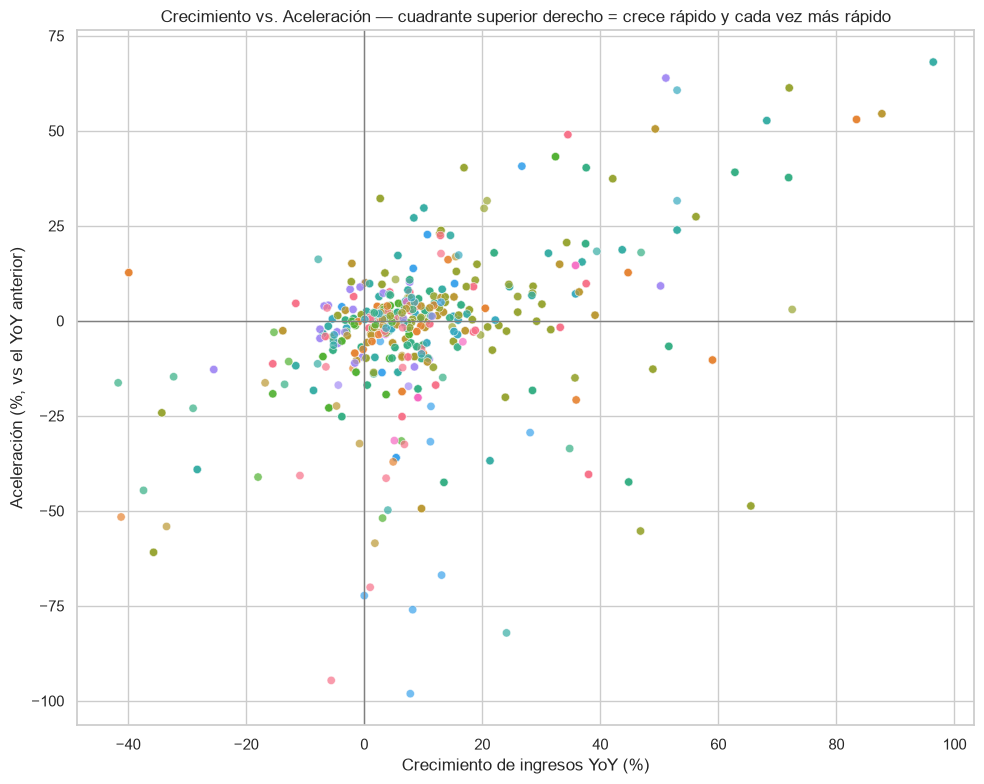

In [7]:
# Recorte para que los outliers extremos (ASTS +1500%, etc.) no aplasten el grafico
c = crecimiento.dropna(subset=["aceleracion_ingresos_pct"])
c = c[c["crecimiento_ingresos_anual_pct"].between(-50, 100) & c["aceleracion_ingresos_pct"].between(-100, 100)]

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=c, x="crecimiento_ingresos_anual_pct", y="aceleracion_ingresos_pct",
                 hue="sector", alpha=0.7, ax=ax, legend=False)
ax.axhline(0, color="grey", linewidth=1)
ax.axvline(0, color="grey", linewidth=1)
ax.set_xlabel("Crecimiento de ingresos YoY (%)")
ax.set_ylabel("Aceleración (%, vs el YoY anterior)")
ax.set_title("Crecimiento vs. Aceleración — cuadrante superior derecho = crece rápido y cada vez más rápido")
plt.tight_layout()
plt.show()

## 5. Precios y retornos (5 años)

Retorno total usando `adj_close` (ya ajustado por splits/dividendos) entre la primera y la última fecha disponible por ticker.

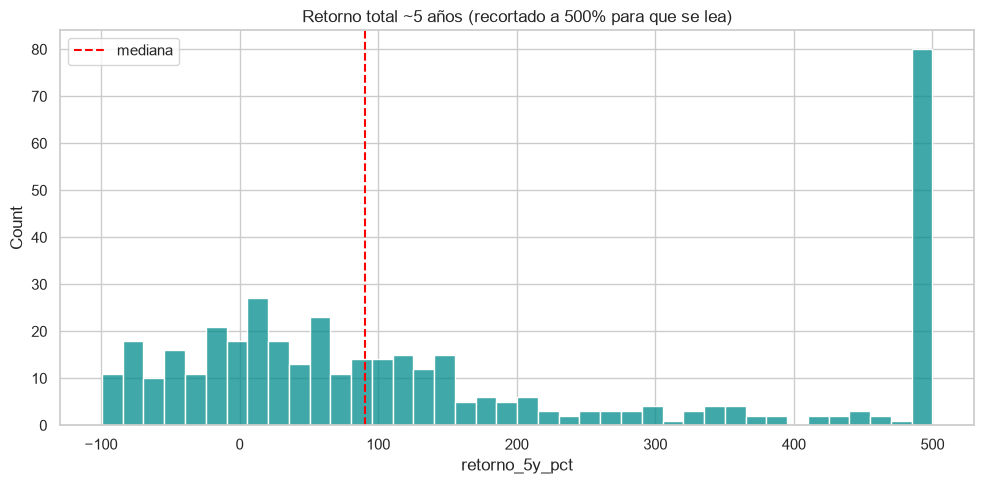

Top 10 retorno 5y:


,ticker_usd,nombre_empresa,retorno_5y_pct
411,YPFD,Ypf,9064.643289
367,TRAN,Transener,8168.498708
229,METR,Metrogas,6799.911290
88,CGPA2,Camuzzi Gas Pampeana,5236.741496
357,TGNO4,Transportadora Gas Del Norte,5001.393749
141,GBAN,Gas Natural Ban,4953.394307
335,SNDK,Sandisk Corporation,4838.333469
325,SEMI,Molinos Juan Semino,4748.184828
192,IRSA,Irsa,4581.903303
358,TGSU2,Transportadora Gas Del Sur,4574.089145



Bottom 10 retorno 5y:


,ticker_usd,nombre_empresa,retorno_5y_pct
340,SPCE,Virgin Galactic Holdings Inc,-99.370312
162,HAPV3,Hapvida Participacoes I Investimentos Sa,-97.232986
56,BIOX,Bioceres Crop Solutions,-97.166667
231,MGLU3,Magazine Luiza S.A,-96.033029
323,SDA,Suncar Technology Group,-94.663951
334,SNAP,Snap Inc,-92.517946
45,BAK,Braskem Sa,-91.160541
257,NIO,Nio Inc,-90.730192
120,ECOG,Ecogas Inversiones S.A,-90.667125
384,UPST,Upstart Holdings Inc,-88.147743


In [8]:
precios_ordenado = precios.sort_values(["ticker_usd", "fecha"])
primero = precios_ordenado.groupby("ticker_usd").first()["adj_close"]
ultimo = precios_ordenado.groupby("ticker_usd").last()["adj_close"]

retornos = ((ultimo / primero) - 1) * 100
retornos = retornos.rename("retorno_5y_pct").reset_index()
retornos = retornos.merge(dim_empresa[["ticker_usd", "nombre_empresa", "sector"]], on="ticker_usd")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(retornos["retorno_5y_pct"].clip(-100, 500), bins=40, ax=ax, color="darkcyan")
ax.axvline(retornos["retorno_5y_pct"].median(), color="red", linestyle="--", label="mediana")
ax.set_title("Retorno total ~5 años (recortado a 500% para que se lea)")
ax.legend()
plt.tight_layout()
plt.show()

print("Top 10 retorno 5y:")
display(retornos.nlargest(10, "retorno_5y_pct")[["ticker_usd", "nombre_empresa", "retorno_5y_pct"]])
print("\nBottom 10 retorno 5y:")
display(retornos.nsmallest(10, "retorno_5y_pct")[["ticker_usd", "nombre_empresa", "retorno_5y_pct"]])

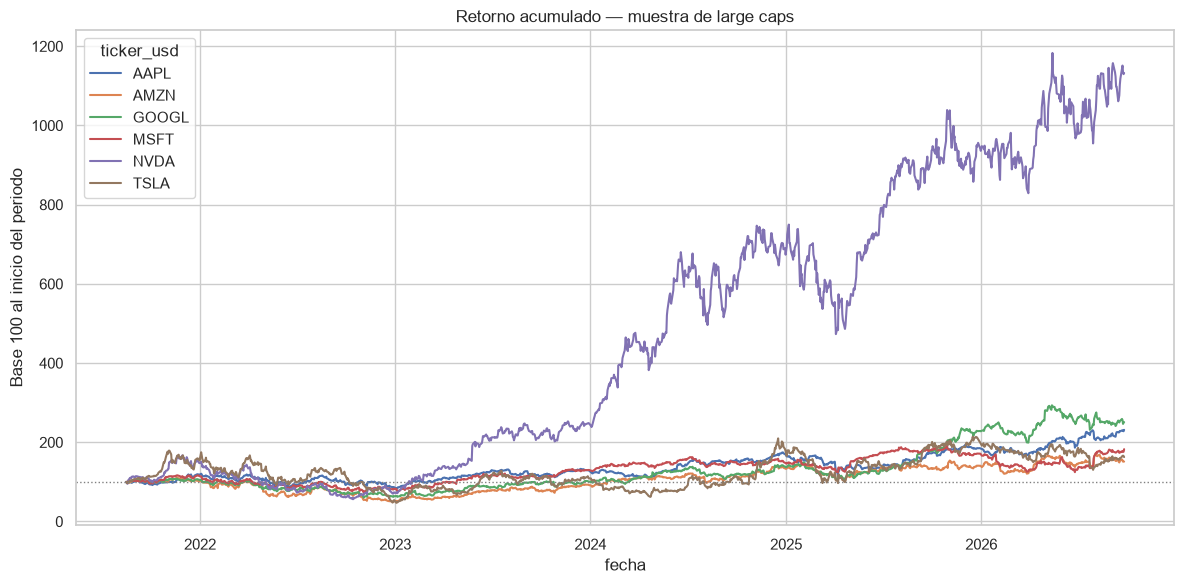

In [9]:
muestra = ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "TSLA"]
p = precios[precios["ticker_usd"].isin(muestra)].sort_values(["ticker_usd", "fecha"]).copy()
p["retorno_acumulado"] = p.groupby("ticker_usd")["adj_close"].transform(lambda s: s / s.iloc[0] * 100)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=p, x="fecha", y="retorno_acumulado", hue="ticker_usd", ax=ax)
ax.axhline(100, color="grey", linewidth=1, linestyle=":")
ax.set_ylabel("Base 100 al inicio del periodo")
ax.set_title("Retorno acumulado — muestra de large caps")
plt.tight_layout()
plt.show()

## 6. Value vs Growth

¿Hay empresas creciendo fuerte que el mercado todavía no le puso un P/E alto? Cuadrante inferior derecho = crece mucho y cotiza barata (candidatas a mirar más de cerca).

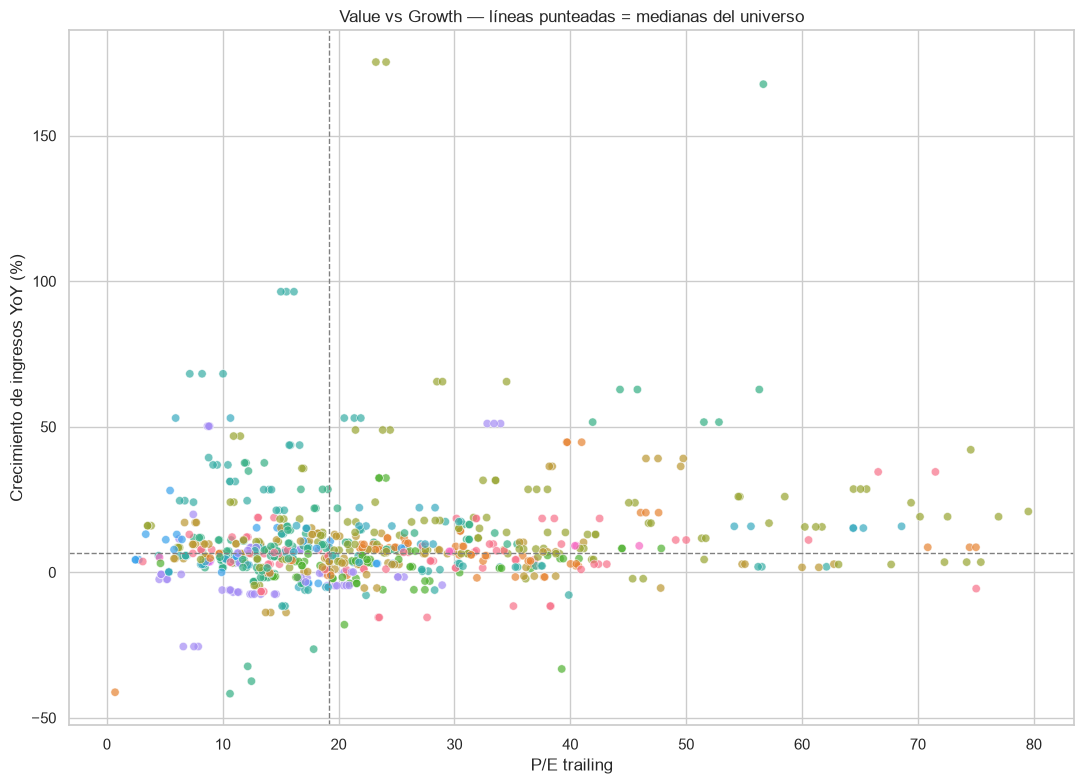

,ticker_usd,nombre_empresa,sector,pe_trailing,crecimiento_ingresos_anual_pct
85,CDE,Coeur D'Alene Mines Cor,Basic Materials,15.50,96.4
424,CDE,Coeur D'Alene Mines Cor,Basic Materials,16.15,96.4
778,CDE,Coeur D'Alene Mines Cor,Basic Materials,15.02,96.4
830,GFI,Gold Fields Ltd,Basic Materials,7.16,68.2
476,GFI,Gold Fields Ltd,Basic Materials,8.22,68.2
135,GFI,Gold Fields Ltd,Basic Materials,10.03,68.2
1059,CVH,Cablevisión Holding S.A,Communication Services,5.94,53.0
1108,TECO2,Telecom Argentina,Communication Services,10.67,53.0
1033,VIST,Vista Oil & Gas Sab De,Energy,8.80,50.2
679,VIST,Vista Oil & Gas Sab De,Energy,8.87,50.2


In [10]:
vg = metrics.merge(dim_empresa[["ticker_usd", "nombre_empresa", "sector"]], on="ticker_usd")
vg = vg.dropna(subset=["pe_trailing", "crecimiento_ingresos_anual_pct"])
vg = vg[(vg["pe_trailing"] > 0) & (vg["pe_trailing"] < 80)]  # PE negativo/absurdo distorsiona el grafico

mediana_pe = vg["pe_trailing"].median()
mediana_crec = vg["crecimiento_ingresos_anual_pct"].median()

fig, ax = plt.subplots(figsize=(11, 8))
sns.scatterplot(data=vg, x="pe_trailing", y="crecimiento_ingresos_anual_pct", hue="sector", alpha=0.7, ax=ax, legend=False)
ax.axhline(mediana_crec, color="grey", linewidth=1, linestyle="--")
ax.axvline(mediana_pe, color="grey", linewidth=1, linestyle="--")
ax.set_xlabel("P/E trailing")
ax.set_ylabel("Crecimiento de ingresos YoY (%)")
ax.set_title("Value vs Growth — líneas punteadas = medianas del universo")
plt.tight_layout()
plt.show()

# Candidatas: crecen mas que la mediana con PE por debajo de la mediana
candidatas = vg[(vg["crecimiento_ingresos_anual_pct"] > mediana_crec) & (vg["pe_trailing"] < mediana_pe)]
candidatas.sort_values("crecimiento_ingresos_anual_pct", ascending=False)[
    ["ticker_usd", "nombre_empresa", "sector", "pe_trailing", "crecimiento_ingresos_anual_pct"]
].head(20)

## 7. Clasificación Peter Lynch (capa Gold)

Viene de `gold/lynch.py`, que arma la vista `gold_lynch` en el warehouse — reglas basadas en "Un paso por delante de Wall Street" (6 categorías, heurística de PEG, checklist de la "empresa perfecta"). Todas las columnas van prefijadas `lynch_` a propósito: mañana va a haber `gold/quant.py`, `gold/technical.py`, etc., cada uno con su propio prefijo, para que ninguna metodología le pise las columnas a otra.

**Correlo primero desde una terminal** (el notebook solo lee, no crea vistas — evita abrir una segunda conexión de escritura mientras el notebook ya tiene una de solo lectura):
```bash
python gold/lynch.py
```

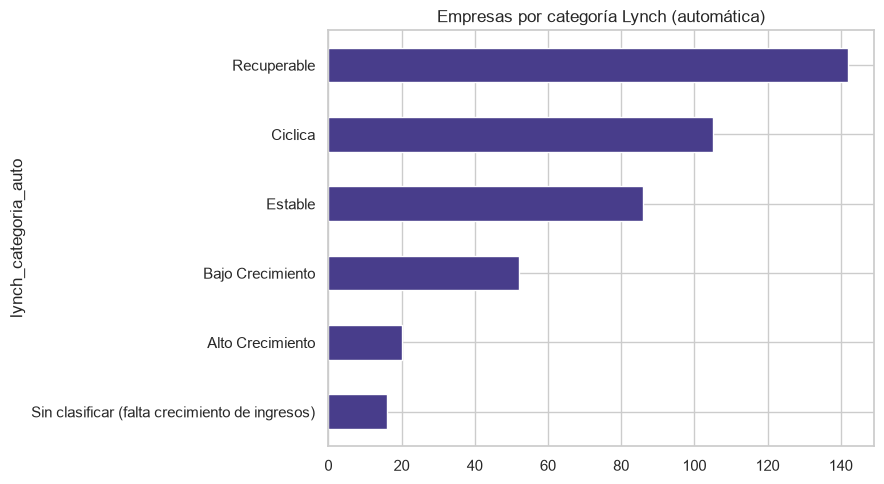

lynch_categoria_auto
Recuperable                                       142
Ciclica                                           105
Estable                                            86
Bajo Crecimiento                                   52
Alto Crecimiento                                   20
Sin clasificar (falta crecimiento de ingresos)     16
Name: count, dtype: int64

In [11]:
lynch = con.execute("SELECT * FROM gold_lynch").fetchdf()

fig, ax = plt.subplots(figsize=(9, 5))
lynch["lynch_categoria_auto"].value_counts().plot(kind="barh", ax=ax, color="darkslateblue")
ax.set_title("Empresas por categoría Lynch (automática)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

lynch["lynch_categoria_auto"].value_counts()

In [12]:
print("Top 15 por lynch_checklist_score:")
display(lynch.sort_values(["lynch_checklist_score", "crecimiento_ingresos_anual_pct"], ascending=False)
        [["ticker_usd", "nombre_empresa", "lynch_categoria_auto", "lynch_checklist_score",
          "lynch_valuacion_peg", "crecimiento_ingresos_anual_pct"]].head(15))

print("\n'Alto Crecimiento' con PEG barato/muy barato (growth a precio razonable):")
gpr = lynch[(lynch["lynch_categoria_auto"] == "Alto Crecimiento")
            & (lynch["lynch_valuacion_peg"].isin(["Muy barata", "Barata"]))]
display(gpr.sort_values("peg_ratio")[["ticker_usd", "nombre_empresa", "crecimiento_ingresos_anual_pct", "peg_ratio"]])

print(f"\nActivo oculto potencial (0 < P/B < 1): {lynch['lynch_activo_oculto_potencial'].sum()} empresas")

Top 15 por lynch_checklist_score:


,ticker_usd,nombre_empresa,lynch_categoria_auto,lynch_checklist_score,lynch_valuacion_peg,crecimiento_ingresos_anual_pct
133,GLOB,Globant S.A,Recuperable,4,Barata,1.6
333,WBO,Weibo Corporation,Bajo Crecimiento,4,Sin dato,0.1
40,BIDU,"Baidu, Inc",Recuperable,4,Barata,-3.0
401,LONG,Longvie,Recuperable,4,Sin dato,-16.8
402,A3,Matba Rofex S.A,Alto Crecimiento,3,Sin dato,46.9
348,SKHY,Sk Hynix Inc,Ciclica,3,Muy barata,46.8
356,ALUA,Aluar,Ciclica,3,Sin dato,39.4
280,TSM,Taiwan Semic. Manuf,Alto Crecimiento,3,Barata,31.6
416,TXAR,Ternium Argentina Sa,Recuperable,3,Sin dato,24.1
374,CTIO,Consultatio,Recuperable,3,Sin dato,16.7



'Alto Crecimiento' con PEG barato/muy barato (growth a precio razonable):


,ticker_usd,nombre_empresa,crecimiento_ingresos_anual_pct,peg_ratio
214,NU,Nu Holdings Ltd/Cayman,28.5,0.63
78,SCHW,Charles Schwab Corp,22.0,0.84
280,TSM,Taiwan Semic. Manuf,31.6,0.86
93,GLW,Corning Incorporated,19.1,0.95
117,META,"Facebook, Inc",22.2,0.98



Activo oculto potencial (0 < P/B < 1): 65 empresas


## 8. Vista por acción: detalle + comparables

Esto es el paso después del screening: ya identificamos candidatas (NU, META) en las secciones anteriores — acá se arma la vista de "seleccioné una acción, quiero el detalle", con series reales (no solo el % de crecimiento) y comparación contra la competencia. Datos de `fact_income_statement_annual`, `fact_eps_trimestral`, `fact_balance_cashflow_annual` (`analisis_fundamental_pesado.py`) y `gold_comparables` (`gold/comparables.py`).

El waterfall de márgenes no aplica a NU: bancos/fintechs no reportan Cost Of Revenue/Gross Profit en el formato estándar de Yahoo (no es un bug, es cómo reportan) — el gráfico lo avisa en vez de mostrar algo vacío o engañoso.

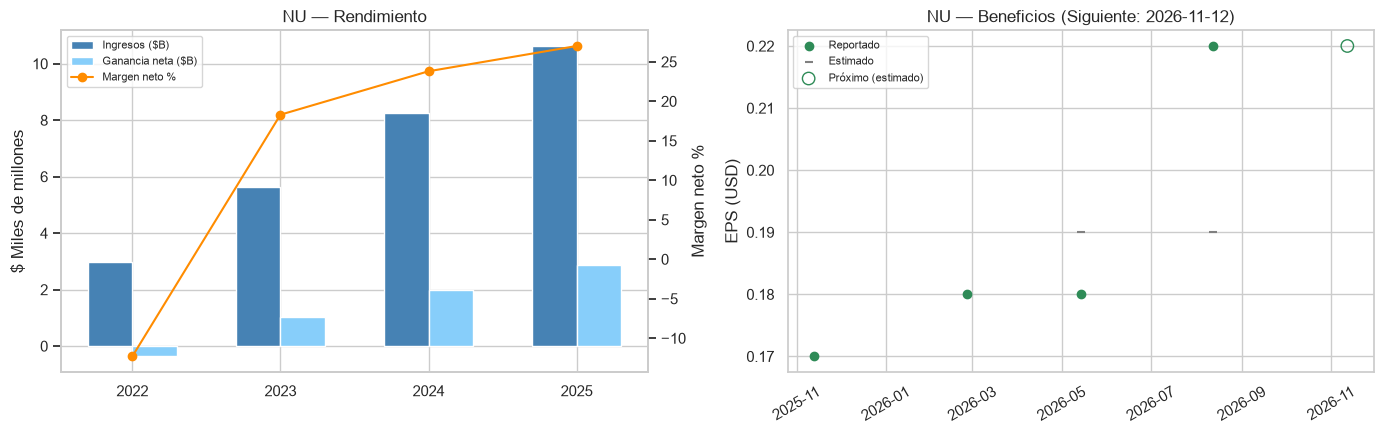

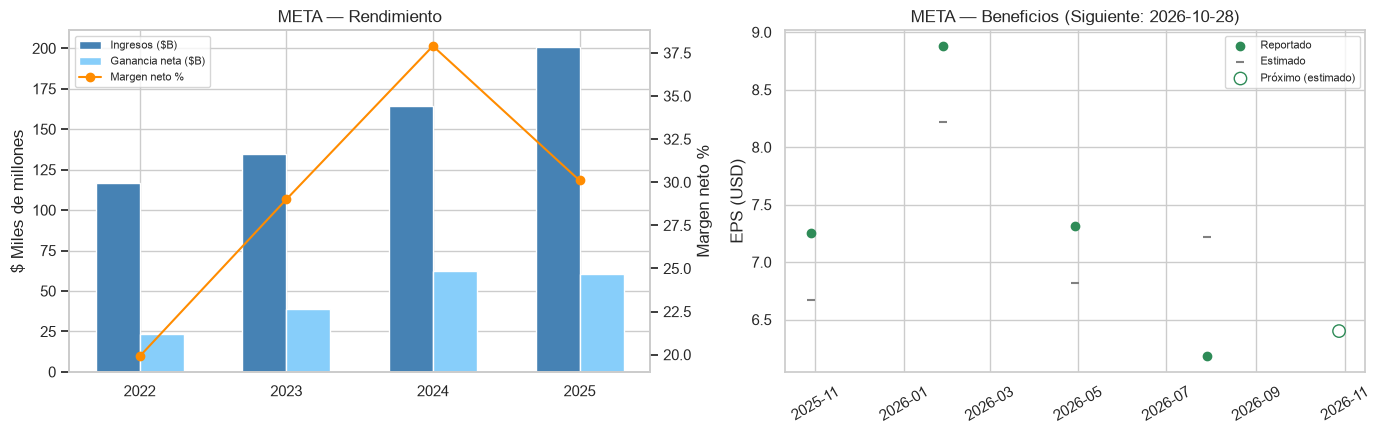

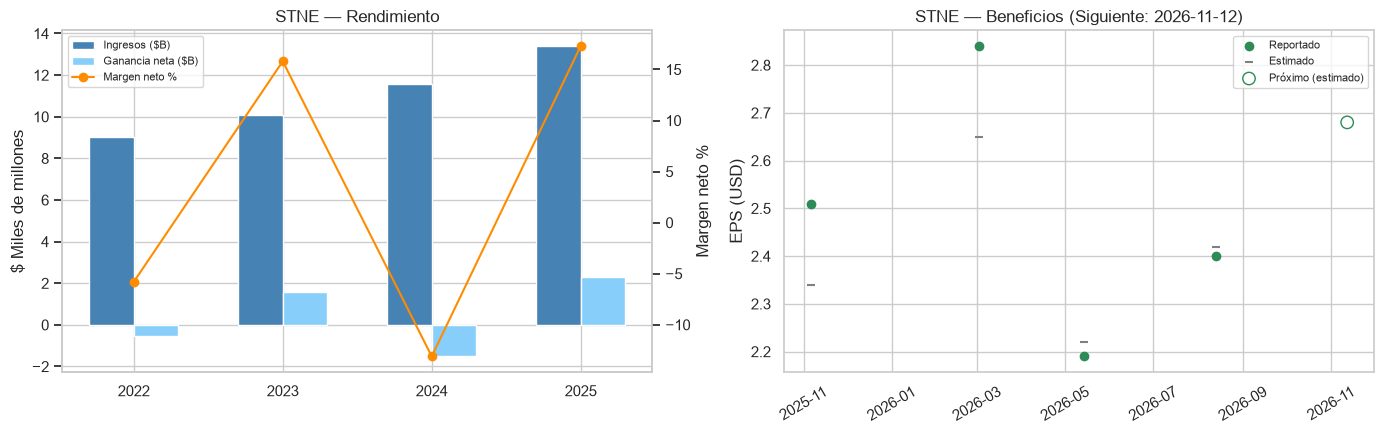

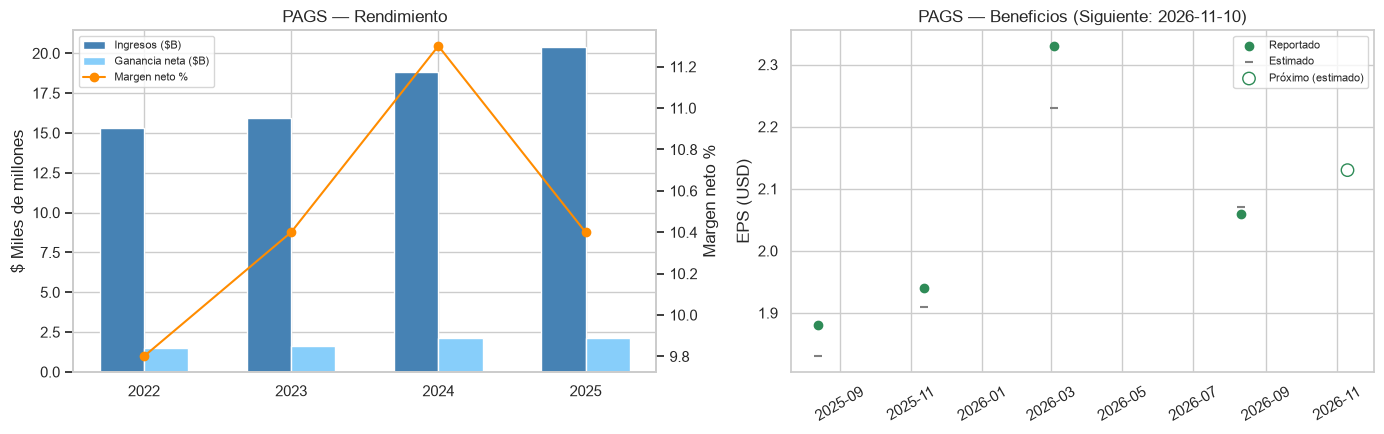

In [13]:
def grafico_rendimiento(ticker: str, ax_izq):
    """Ingresos / Ingresos netos (barras) + Margen neto % (linea) por año -- estilo 'Rendimiento'."""
    serie = con.execute(
        "SELECT * FROM fact_income_statement_annual WHERE ticker_usd = ? ORDER BY fecha_balance", [ticker]
    ).fetchdf()
    anios = serie["fecha_balance"].dt.year

    ax_izq.bar(anios - 0.15, serie["ingresos"] / 1e9, width=0.3, label="Ingresos ($B)", color="steelblue")
    ax_izq.bar(anios + 0.15, serie["ganancia_neta"] / 1e9, width=0.3, label="Ganancia neta ($B)", color="lightskyblue")
    ax_izq.set_ylabel("$ Miles de millones")

    ax_der = ax_izq.twinx()
    ax_der.plot(anios, serie["margen_neto_pct"], color="darkorange", marker="o", label="Margen neto %")
    ax_der.set_ylabel("Margen neto %")
    ax_der.grid(False)

    ax_izq.set_title(f"{ticker} — Rendimiento")
    ax_izq.set_xticks(anios)
    l1, lb1 = ax_izq.get_legend_handles_labels()
    l2, lb2 = ax_der.get_legend_handles_labels()
    ax_izq.legend(l1 + l2, lb1 + lb2, loc="upper left", fontsize=8)


def grafico_beneficios(ticker: str, ax):
    """EPS estimado vs. reportado por trimestre, con el proximo informe marcado aparte -- estilo 'Beneficios'."""
    serie = con.execute(
        "SELECT * FROM fact_eps_trimestral WHERE ticker_usd = ? ORDER BY fecha_reporte", [ticker]
    ).fetchdf()
    pasado = serie.dropna(subset=["eps_reportado"])
    futuro = serie[serie["eps_reportado"].isna()]

    ax.scatter(pasado["fecha_reporte"], pasado["eps_reportado"], color="seagreen", label="Reportado", zorder=3)
    ax.scatter(pasado["fecha_reporte"], pasado["eps_estimado"], color="grey", marker="_", label="Estimado", zorder=2)
    if not futuro.empty:
        ax.scatter(futuro["fecha_reporte"], futuro["eps_estimado"], facecolors="none",
                   edgecolors="seagreen", s=80, label="Próximo (estimado)", zorder=3)
        siguiente = futuro["fecha_reporte"].iloc[0].date()
        ax.set_title(f"{ticker} — Beneficios (Siguiente: {siguiente})")
    else:
        ax.set_title(f"{ticker} — Beneficios")
    ax.set_ylabel("EPS (USD)")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)


for ticker in ["NU", "META", "STNE", "PAGS"]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    grafico_rendimiento(ticker, axes[0])
    grafico_beneficios(ticker, axes[1])
    plt.tight_layout()
    plt.show()

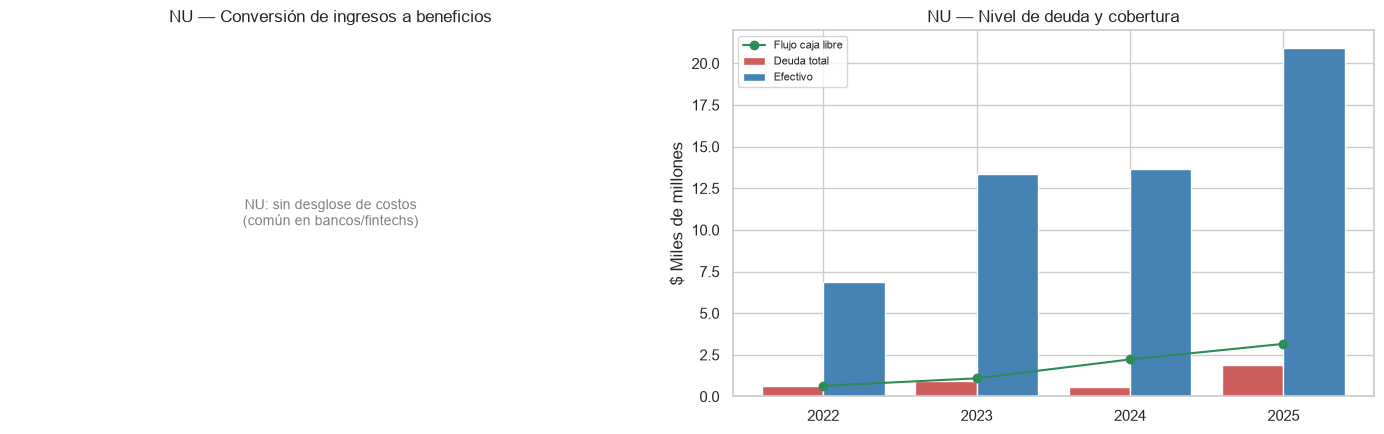

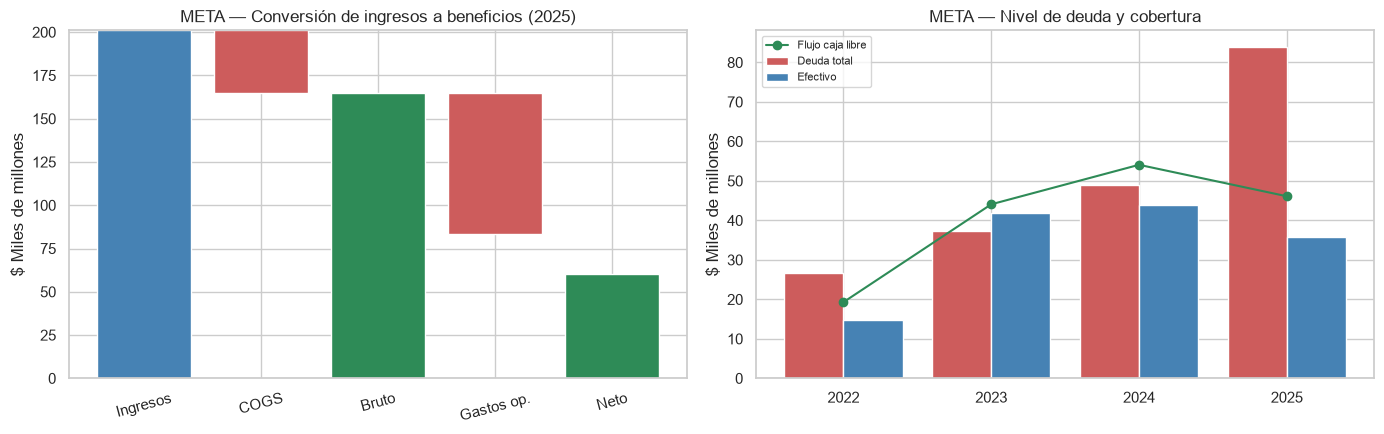

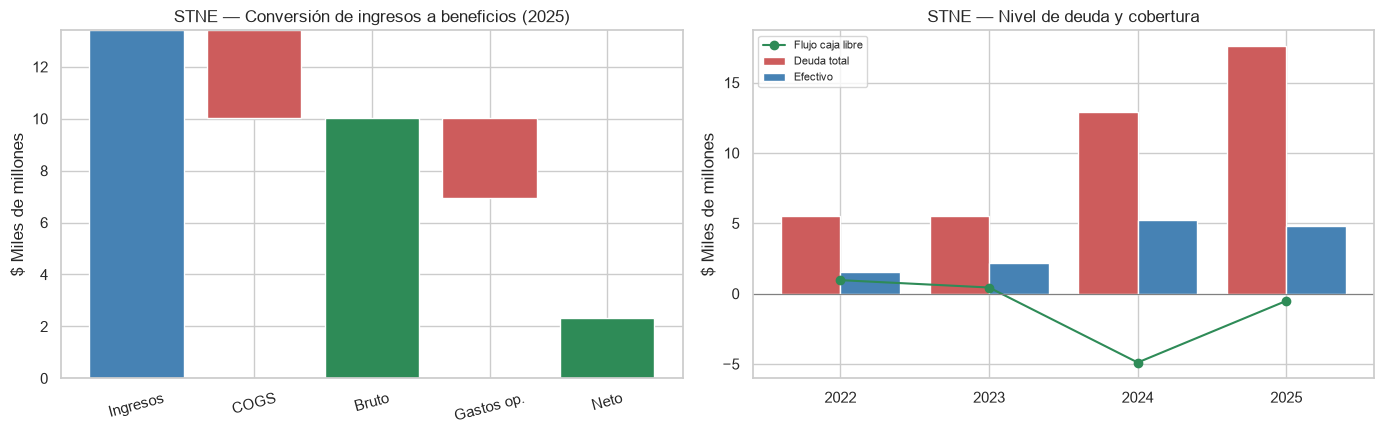

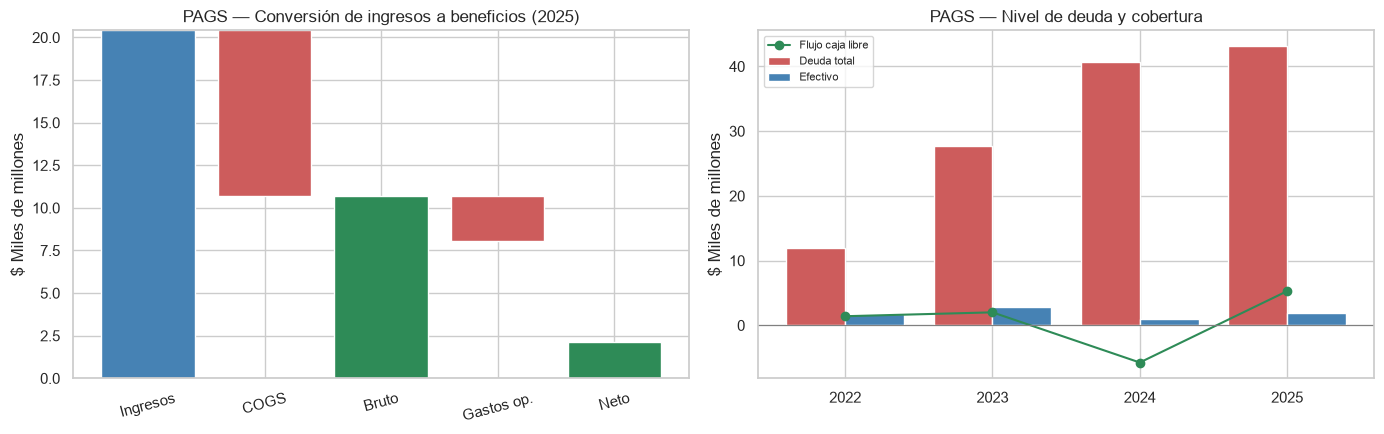

In [14]:
def grafico_waterfall(ticker: str, ax):
    """Ingresos -> COGS -> Beneficio bruto -> Gastos operativos -> Ganancia neta,
    del ultimo balance anual. Bancos/fintechs (ej. NU) no reportan Cost Of
    Revenue/Gross Profit en formato estandar -- ahi se muestra un aviso en vez
    de un grafico vacio o enganoso."""
    fila = con.execute(
        "SELECT * FROM fact_income_statement_annual WHERE ticker_usd = ? "
        "ORDER BY fecha_balance DESC LIMIT 1", [ticker]
    ).fetchdf()
    campos = ["ingresos", "costo_ingresos", "beneficio_bruto", "gastos_operativos", "ganancia_neta"]
    if fila.empty or fila.iloc[0][campos].isna().any():
        ax.text(0.5, 0.5, f"{ticker}: sin desglose de costos\n(común en bancos/fintechs)",
                ha="center", va="center", transform=ax.transAxes, color="grey", fontsize=10)
        ax.set_title(f"{ticker} — Conversión de ingresos a beneficios")
        ax.axis("off")
        return

    f = fila.iloc[0]
    etiquetas = ["Ingresos", "COGS", "Bruto", "Gastos op.", "Neto"]
    deltas = [f["ingresos"], -f["costo_ingresos"], 0, -f["gastos_operativos"], 0]
    es_subtotal = [False, False, True, False, True]

    acumulado = 0
    for i, (etiqueta, delta, subtotal) in enumerate(zip(etiquetas, deltas, es_subtotal)):
        if subtotal:
            valor = f["beneficio_bruto"] if etiqueta == "Bruto" else f["ganancia_neta"]
            ax.bar(i, valor / 1e9, color="seagreen")
            acumulado = valor
        else:
            ax.bar(i, delta / 1e9, bottom=acumulado / 1e9, color="steelblue" if delta > 0 else "indianred")
            acumulado += delta

    ax.set_xticks(range(len(etiquetas)))
    ax.set_xticklabels(etiquetas, rotation=15)
    ax.set_ylabel("$ Miles de millones")
    ax.set_title(f"{ticker} — Conversión de ingresos a beneficios ({f['fecha_balance'].year})")


def grafico_deuda(ticker: str, ax):
    """Deuda total y efectivo (barras) + flujo de caja libre (linea) por año."""
    serie = con.execute(
        "SELECT * FROM fact_balance_cashflow_annual WHERE ticker_usd = ? ORDER BY fecha_balance", [ticker]
    ).fetchdf()
    if serie.empty:
        ax.text(0.5, 0.5, f"{ticker}: sin datos de balance/cashflow", ha="center", va="center",
                transform=ax.transAxes, color="grey")
        ax.axis("off")
        return

    anios = serie["fecha_balance"].dt.year
    ax.bar(anios - 0.2, serie["deuda_total"] / 1e9, width=0.4, label="Deuda total", color="indianred")
    ax.bar(anios + 0.2, serie["efectivo"] / 1e9, width=0.4, label="Efectivo", color="steelblue")
    ax.plot(anios, serie["flujo_caja_libre"] / 1e9, color="seagreen", marker="o", label="Flujo caja libre")
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_ylabel("$ Miles de millones")
    ax.set_title(f"{ticker} — Nivel de deuda y cobertura")
    ax.set_xticks(anios)
    ax.legend(fontsize=8)


for ticker in ["NU", "META", "STNE", "PAGS"]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    grafico_waterfall(ticker, axes[0])
    grafico_deuda(ticker, axes[1])
    plt.tight_layout()
    plt.show()

In [15]:
import sys
sys.path.insert(0, "..")
from gold.comparables import SQL_VISTA as SQL_COMPARABLES, pares_similares

comp = con.execute(SQL_COMPARABLES.replace("CREATE OR REPLACE VIEW", "CREATE OR REPLACE TEMP VIEW"))
# TEMP VIEW porque esta conexion es read_only: no puede escribir vistas
# permanentes en el archivo, pero una vista temporal solo vive en la sesion.

for ticker in ["NU", "META", "STNE", "PAGS"]:
    fila = con.execute("SELECT * FROM gold_comparables WHERE ticker_usd = ?", [ticker]).fetchdf().iloc[0]
    print(f"=== {ticker} vs. sector {fila['sector']} ({fila['comp_pares_en_sector']} pares) ===")
    print(f"  P/E {fila['pe_trailing']:.1f} vs mediana {fila['comp_pe_mediana_sector']:.1f} "
          f"({fila['comp_pe_vs_sector_pct']:+.0f}%) | "
          f"Margen {fila['margen_neto_pct']:.1f}% vs {fila['comp_margen_neto_mediana_sector']:.1f}% "
          f"({fila['comp_margen_vs_sector_pp']:+.1f}pp) | "
          f"Crecimiento percentil {fila['comp_percentil_crecimiento_en_sector']:.0f} del sector")
    display(pares_similares(con, ticker))
    print()

=== NU vs. sector Financial Services (62 pares) ===
  P/E 16.8 vs mediana 14.2 (+18%) | Margen 42.7% vs 26.2% (+16.5pp) | Crecimiento percentil 84 del sector


,ticker_usd,nombre_empresa,market_cap,pe_trailing,crecimiento_ingresos_anual_pct,margen_neto_pct,roe_pct
0,COIN,Coinbase Global Inc,5.060128e+10,NaN,9.4,-16.3,-7.8
1,PYPL,"Paypal Holdings, Inc",4.643441e+10,10.26,4.3,14.4,24.5
2,KB,Kb Financial Group Inc,4.465016e+10,10.31,5.6,36.5,10.2
3,XYZ,Block Inc,4.404428e+10,130.91,0.3,1.4,1.6
4,BSBR,Banco Santander (Brasil),4.275378e+10,16.79,-3.8,28.7,11.2



=== META vs. sector Communication Services (27 pares) ===
  P/E 27.0 vs mediana 16.1 (+67%) | Margen 29.8% vs 9.4% (+20.4pp) | Crecimiento percentil 85 del sector


,ticker_usd,nombre_empresa,market_cap,pe_trailing,crecimiento_ingresos_anual_pct,margen_neto_pct,roe_pct
0,NFLX,"Netflix, Inc",2.882696e+11,21.77,15.9,28.2,49.5
1,VZ,Verizon Communications,1.939449e+11,12.16,2.5,11.6,15.8
2,DISN,The Walt Disney Company,1.823209e+11,21.77,3.4,8.7,8.0
3,TMUS,T-Mobile Us Inc,1.785462e+11,17.41,8.5,11.5,18.0
4,T,At & T Inc,1.706244e+11,8.22,2.7,16.9,18.3



=== STNE vs. sector Financial Services (62 pares) ===
  P/E 3.5 vs mediana 14.2 (-75%) | Margen 24.7% vs 26.2% (-1.6pp) | Crecimiento percentil 79 del sector


,ticker_usd,nombre_empresa,market_cap,pe_trailing,crecimiento_ingresos_anual_pct,margen_neto_pct,roe_pct
0,UPST,Upstart Holdings Inc,2.241119e+09,44.29,62.8,4.7,7.9
1,PAGS,Pagseguro Digital Ltd,2.453250e+09,6.18,8.5,10.9,14.5
2,FNMA,Fed.Natl Mort-Fannie Mae Esc,5.084004e+09,109.75,-5.3,54.3,13.8
3,RIOT,Riot Platforms Inc,8.113099e+09,NaN,71.9,-196.3,-48.2
4,XP,Xp Inc,1.026557e+10,10.37,7.3,28.5,22.6



=== PAGS vs. sector Financial Services (62 pares) ===
  P/E 6.2 vs mediana 14.2 (-56%) | Margen 10.9% vs 26.2% (-15.4pp) | Crecimiento percentil 52 del sector


,ticker_usd,nombre_empresa,market_cap,pe_trailing,crecimiento_ingresos_anual_pct,margen_neto_pct,roe_pct
0,UPST,Upstart Holdings Inc,2.241119e+09,44.29,62.8,4.7,7.9
1,STNE,Stoneco Ltd,2.137622e+09,3.52,16.0,24.7,34.0
2,FNMA,Fed.Natl Mort-Fannie Mae Esc,5.084004e+09,109.75,-5.3,54.3,13.8
3,RIOT,Riot Platforms Inc,8.113099e+09,NaN,71.9,-196.3,-48.2
4,XP,Xp Inc,1.026557e+10,10.37,7.3,28.5,22.6


## 9. Sensibilidad a tasas (capa Gold, macro)

Viene de `gold/macro_sensitivity.py`, que arma `gold_macro_sensitivity` — correlación entre el retorno diario de cada empresa y el delta diario de la tasa del Treasury (UST10Y/UST30Y), calculada con datos reales de `fact_precios_daily` × `fact_macro_daily` (no una regla por categoría).

Resultado no obvio: no son las "Alto Crecimiento" (PEG alto) las más golpeadas por la tasa, como predice la teoría clásica de compresión de múltiplos. En este universo pesa más el efecto **bond-proxy**: utilities/REITs (se compran por el dividendo, que compite directo con el yield del Treasury) y mineras de oro (el oro compite con el bono como reserva de valor) son las más negativamente correlacionadas. Petroleras y bancos se benefician (mayor tasa = mayor margen de intermediación / la tasa sube junto con la inflación energética).

**Correlo primero desde una terminal** (igual que Lynch/Comparables):
```bash
python gold/macro_sensitivity.py
```

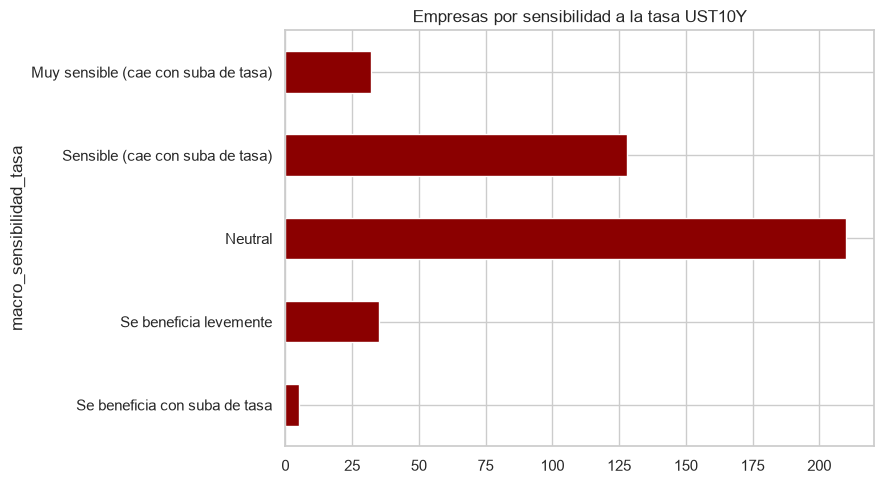

Top 10 mas sensibles NEGATIVAMENTE (caen cuando sube la tasa):


,ticker_usd,nombre_empresa,sector,lynch_categoria_auto,macro_corr_ret_vs_ust10y
72,NGG,Cedears De National Grid Plc,Utilities,Bajo Crecimiento,-0.343
339,SHW,The Sherwin-Williams Co,Basic Materials,Ciclica,-0.295
289,HD,The Home Depot Inc,Consumer Cyclical,Bajo Crecimiento,-0.275
133,GFI,Gold Fields Ltd,Basic Materials,Ciclica,-0.272
237,O,Realty Income Corp,Real Estate,Estable,-0.270
141,HMY,Harmony Gold Mining Co,Basic Materials,Ciclica,-0.259
11,AEM,Agnico Eagle Mines Limi,Basic Materials,Ciclica,-0.259
111,EFX,Equifax Inc,Industrials,Ciclica,-0.247
202,NEE,Nextera Energy Inc,Utilities,Estable,-0.232
51,B,Barrick Mining Corporation,Basic Materials,Ciclica,-0.232



Top 10 que mas se BENEFICIAN cuando sube la tasa:


,ticker_usd,nombre_empresa,sector,lynch_categoria_auto,macro_corr_ret_vs_ust10y
331,IBKR,Interactive Brokers Group Inc,Financial Services,Estable,0.186
61,BP,Bp P.L.C,Energy,Recuperable,0.177
87,COP,Conocophillips,Energy,Ciclica,0.177
138,HAL,Halliburton Co,Energy,Recuperable,0.166
114,XOM,Exxon Mobil Corporation,Energy,Ciclica,0.156
231,PSX,Phillips 66,Energy,Ciclica,0.149
77,CVX,Chevron Corp,Energy,Recuperable,0.143
254,SLB,Schlumberger Limited,Energy,Recuperable,0.141
21,AIG,American International,Financial Services,Bajo Crecimiento,0.134
215,OXY,Occidental Petroleum Corporation,Energy,Recuperable,0.134



Promedio de correlación por categoría Lynch (el efecto bond-proxy domina sobre PEG):


lynch_categoria_auto
Bajo Crecimiento                                 -0.070
Sin clasificar (falta crecimiento de ingresos)   -0.068
Estable                                          -0.048
Ciclica                                          -0.034
Recuperable                                      -0.024
Alto Crecimiento                                 -0.011
Name: macro_corr_ret_vs_ust10y, dtype: float64

In [16]:
macro_sens = con.execute("""
    SELECT m.*, d.nombre_empresa, d.sector, l.lynch_categoria_auto
    FROM gold_macro_sensitivity m
    JOIN dim_empresa d USING (ticker_usd)
    LEFT JOIN gold_lynch l USING (ticker_usd)
""").fetchdf()

fig, ax = plt.subplots(figsize=(9, 5))
orden_sens = ["Muy sensible (cae con suba de tasa)", "Sensible (cae con suba de tasa)", "Neutral",
              "Se beneficia levemente", "Se beneficia con suba de tasa"]
macro_sens["macro_sensibilidad_tasa"].value_counts().reindex(orden_sens).plot(
    kind="barh", ax=ax, color="darkred"
)
ax.set_title("Empresas por sensibilidad a la tasa UST10Y")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 mas sensibles NEGATIVAMENTE (caen cuando sube la tasa):")
display(macro_sens.sort_values("macro_corr_ret_vs_ust10y").head(10)[
    ["ticker_usd", "nombre_empresa", "sector", "lynch_categoria_auto", "macro_corr_ret_vs_ust10y"]
])

print("\nTop 10 que mas se BENEFICIAN cuando sube la tasa:")
display(macro_sens.sort_values("macro_corr_ret_vs_ust10y", ascending=False).head(10)[
    ["ticker_usd", "nombre_empresa", "sector", "lynch_categoria_auto", "macro_corr_ret_vs_ust10y"]
])

print("\nPromedio de correlación por categoría Lynch (el efecto bond-proxy domina sobre PEG):")
display(macro_sens.groupby("lynch_categoria_auto")["macro_corr_ret_vs_ust10y"].mean().round(3).sort_values())

## Próximos pasos

- `fact_metrics_daily` ya tiene varios días de historial acumulado — a medida que pase más tiempo el checklist de Lynch va a poder evaluar recompra de acciones (necesita >= 30 días de historial de `shares_outstanding`).
- `dim_empresa.lynch_category`/`modelo_negocio` (la versión *curada*, a mano o con LLM) siguen pendientes — la sección 7 ya cubre la versión *automática* (`gold_lynch.lynch_categoria_auto`) que no depende de eso.
- Cada metodología nueva (quant, técnico...) va a su propio archivo en `gold/`, con columnas prefijadas — así conviven sin pisarse en el mismo warehouse.
- Este notebook es la base para los futuros agentes: las mismas queries de acá son las que un agente correría para responder "¿cómo está esta empresa vs. su sector, y qué dice el checklist de Lynch?" en lenguaje natural.